# Classificação de Categoria de Incidentes

Sprint 4 — Machine Learning & Artificial Intelligence — projeto de ML (Locaweb)

Case complementar ao projeto principal: uma segunda aplicação de ML sobre a mesma base de
incidentes, focada em organizar o que já chegou, não em prever o que vai chegar.

## 01 — O problema

Parte dos incidentes P2/P3 chega sem `Categoria` preenchida — e sem categoria, quem faz o
roteamento perde a informação que ajudaria a mandar o incidente para o time certo. A causa
aparece na auditoria da Seção 04: um canal inteiro de abertura parou de categorizar
automaticamente a partir de setembro/2025.

A pergunta deste notebook: dá para prever a `Categoria` de um incidente **no momento da
abertura**, usando só o que já está disponível ali — descrição, produto, prioridade, canal —
sem esperar nenhuma etapa manual do atendimento?

$$
\text{Features conhecidas na abertura}(t) \;\longrightarrow\; \text{Categoria}(t)
$$

Se funcionar, o modelo vira uma sugestão automática de categoria no instante em que o
incidente é aberto — mais útil exatamente onde hoje não existe categoria nenhuma.

Este notebook é complementar ao projeto principal (`EC_Sprint_3_MLOps_PRISM_ML.ipynb`, que
prevê volume agregado de incidentes). O problema aqui é outro — classificação multiclasse no
nível do incidente individual, não série temporal agregada — mas a disciplina é a mesma: split
temporal, auditoria de leakage, decisão por experimento em vez de suposição.

## 02 — Imports e configuração

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.axisbelow"] = True

ARQUIVO = "LW-DATASET.xlsx"

# Colunas de leakage: só existem/ganham valor depois da abertura do incidente.
# Nenhuma delas pode entrar em nenhuma matriz de features (checado por assert na Etapa 06).
COLUNAS_LEAKAGE = [
    "Subcategoria", "Status", "Entrou para KPI?", "KPI Violado?", "Duração",
    "Resolvido", "Encerrado", "Código de fechamento", "Solução", "Incidente Pai",
]

print("Configuração ok. RANDOM_STATE =", RANDOM_STATE)

Configuração ok. RANDOM_STATE = 42


## 03 — Carregamento de `LW-DATASET.xlsx`

O arquivo está no nível de **incidente individual** (uma linha por chamado).

In [2]:
raw = pd.read_excel(ARQUIVO)
raw.columns = [c.strip() for c in raw.columns]
print(f"linhas x colunas: {raw.shape[0]:,} x {raw.shape[1]}")
raw.head()

linhas x colunas: 122,543 x 19


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               44608 non-null   object        
 3   Categoria             44822 non-null   object        
 4   Subcategoria          44823 non-null   object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  120763 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   object        
 12  Descrição resumida    122543 non-null  object        
 13 

## 04 — Contexto dos dados: por que falta Categoria

Uma taxa de nulidade agregada esconderia o padrão real. Por isso a nulidade de `Categoria` é
lida cruzando canal de abertura (`Aberto por`) com o corte de regime de 01/09/2025 já usado no
projeto principal.

In [4]:
print("Nulos por coluna:")
print(raw.isna().sum()[lambda s: s > 0].sort_values(ascending=False))
print()
print("Cardinalidade das colunas categóricas relevantes:")
for c in ["Prioridade", "Produto", "Categoria", "Subcategoria", "Grupo designado",
          "Item de configuração", "Aberto por"]:
    print(f"  {c}: cardinalidade={raw[c].nunique()}, nulos={raw[c].isna().mean():.1%}")
print()
print("Número duplicado:", raw["Número"].duplicated().sum(),
      "| linhas totalmente duplicadas:", raw.duplicated().sum())
print()
print("Intervalo de datas (Aberto):", raw["Aberto"].min(), "->", raw["Aberto"].max())

Nulos por coluna:
Incidente Pai           107416
Solução                 107243
KPI Violado?             96943
Resolvido                82302
Código de fechamento     81739
Produto                  77935
Categoria                77721
Subcategoria             77720
Item de configuração      1780
dtype: int64

Cardinalidade das colunas categóricas relevantes:
  Prioridade: cardinalidade=5, nulos=0.0%
  Produto: cardinalidade=51, nulos=63.6%
  Categoria: cardinalidade=141, nulos=63.4%
  Subcategoria: cardinalidade=447, nulos=63.4%
  Grupo designado: cardinalidade=17, nulos=0.0%
  Item de configuração: cardinalidade=9171, nulos=1.5%
  Aberto por: cardinalidade=2, nulos=0.0%



Número duplicado: 0 | linhas totalmente duplicadas: 0



Intervalo de datas (Aberto): 2023-01-02 20:19:58 -> 2025-12-31 23:45:18


In [5]:
CORTE_REGIME = pd.Timestamp("2025-09-01")
regime = np.where(raw["Aberto"] < CORTE_REGIME, "pré-regime (< 01/09/2025)", "pós-regime (>= 01/09/2025)")

print("Nulidade de Categoria por canal (Aberto por):")
print(raw.groupby("Aberto por")["Categoria"].apply(lambda s: s.isna().mean()).rename("% nulo"))
print()
print("Nulidade de Categoria por regime:")
print(pd.Series(regime, name="regime").to_frame().join(raw["Categoria"].isna().rename("nulo"))
      .groupby("regime")["nulo"].mean())
print()
print("Nulidade de Categoria por regime x canal:")
print(pd.DataFrame({"regime": regime, "canal": raw["Aberto por"], "nulo": raw["Categoria"].isna()})
      .groupby(["regime", "canal"])["nulo"].mean())

Nulidade de Categoria por canal (Aberto por):
Aberto por
Manual          0.000
Monitoramento   0.745
Name: % nulo, dtype: float64

Nulidade de Categoria por regime:
regime
pré-regime (< 01/09/2025)    0.034
pós-regime (>= 01/09/2025)   0.821
Name: nulo, dtype: float64

Nulidade de Categoria por regime x canal:
regime                      canal        
pré-regime (< 01/09/2025)   Manual          0.000
                            Monitoramento   0.063
pós-regime (>= 01/09/2025)  Manual          0.000
                            Monitoramento   0.867
Name: nulo, dtype: float64


**Leitura:** quem abre manualmente sempre categoriza (0% de nulo, em qualquer período).
Monitoramento não — a nulidade salta de 6,3% para **86,7%** depois de 01/09/2025. A leitura
mais direta: uma automação de categorização parou de funcionar junto com a mudança de regime.

É por isso que os incidentes sem `Categoria` hoje estão concentrados no pós-regime — exatamente
onde este modelo precisa atuar (retomado na Seção 19). Sem duplicidade de `Número` — a base não
precisa de deduplicação.

In [6]:
auditoria = pd.DataFrame(
    [
        ("Número", "identificador",
         "ID único do incidente. 0 duplicatas. Sem valor preditivo."),
        ("Prioridade", "filtro de população + feature",
         "Define a população do problema: só P2 ('2 - Alta') e P3 ('3 - Média') entram. "
         "Mantida também como feature binária (Plano 2, seção 4.1) -- não é possível confirmar apenas com o .xlsx se o valor registrado é a prioridade original da abertura ou uma reclassificação posterior; suposição assumida, não fato confirmado."),
        ("Produto", "feature",
         "Maior associação estrutural com Categoria medida (NMI = 0,698 no TRAIN, seção 08). "
         "Cardinalidade 51 na base bruta completa (Etapa 04); 47 no universo rotulado 2025 e 46 "
         "dentro do TRAIN. Nulos tratados como 'Desconhecido'."),
        ("Categoria", "target",
         "Variável a prever. Só linhas com Categoria não nula entram no treino/validação/teste; "
         "as demais formam o conjunto de aplicação futura."),
        ("Subcategoria", "leakage",
         "Refinamento de Categoria feito durante o atendimento — não existe no momento da abertura."),
        ("Grupo designado", "a validar",
         "Só entra como feature se for confirmado que a atribuição é automática na abertura "
         "(regra de roteamento), não uma alocação manual feita depois."),
        ("Item de configuração", "feature (alta cardinalidade)",
         "Cardinalidade muito alta e concentrada em valores raros — precisa de agrupamento "
         "antes de qualquer encoding (seção de features categóricas)."),
        ("Aberto", "feature temporal / chave do split",
         "Timestamp de abertura. Usado para o split temporal e para extrair hora/dia/mês."),
        ("Resolvido", "leakage", "Só existe após o atendimento."),
        ("Encerrado", "leakage", "Só existe após o encerramento."),
        ("Duração", "leakage", "Calculada a partir de Resolvido/Encerrado."),
        ("Código de fechamento", "leakage", "Só existe após o fechamento."),
        ("Descrição resumida", "feature de texto",
         "Texto livre preenchido na abertura. Base do TF-IDF."),
        ("Solução", "leakage", "Preenchida durante/após o atendimento."),
        ("Aberto por", "feature (canal)",
         "Manual vs. Monitoramento. Associação real com Categoria (NMI = 0,144, seção EDA), "
         "mas distribuição de canal muda muito entre TRAIN e TEST — testado com e sem "
         "(Experimentos 11/12)."),
        ("Incidente Pai", "leakage", "Vínculo estabelecido durante o atendimento, não na abertura."),
        ("Status", "leakage", "Estado do atendimento, não existe (com valor final) na abertura."),
        ("Entrou para KPI?", "leakage", "Classificação de SLA feita durante o ciclo de vida."),
        ("KPI Violado?", "leakage", "Só é conhecido após o desfecho do incidente."),
    ],
    columns=["coluna", "classificação", "motivo"],
)
auditoria

,coluna,classificação,motivo
0,Número,identificador,ID único do incidente. 0 duplicatas. Sem valor...
1,Prioridade,filtro de população + feature,Define a população do problema: só P2 ('2 - Al...
2,Produto,feature,Maior associação estrutural com Categoria medi...
3,Categoria,target,Variável a prever. Só linhas com Categoria não...
4,Subcategoria,leakage,Refinamento de Categoria feito durante o atend...
5,Grupo designado,a validar,Só entra como feature se for confirmado que a ...
6,Item de configuração,feature (alta cardinalidade),Cardinalidade muito alta e concentrada em valo...
7,Aberto,feature temporal / chave do split,Timestamp de abertura. Usado para o split temp...
8,Resolvido,leakage,Só existe após o atendimento.
9,Encerrado,leakage,Só existe após o encerramento.


## 05 — Como a base se comporta ao longo do tempo

Volume, prioridade e canal, antes de decidir a população de modelagem. Estatísticas que
dependem da partição — associação Produto×Categoria, cold-start entre TRAIN/VAL/TEST — ficam
para depois do split (Seções 07-08): só fazem sentido calculadas dentro do TRAIN.

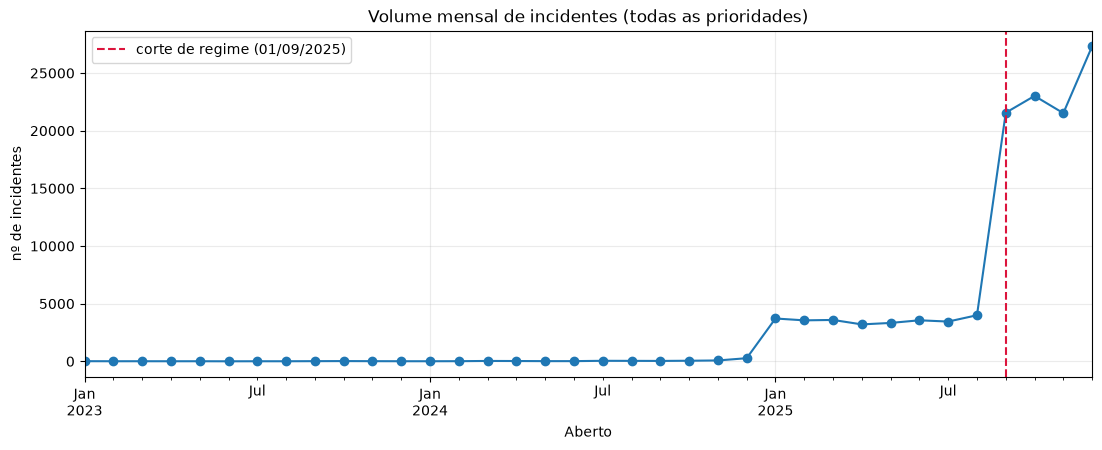

Distribuição por ano:
Aberto
2023       110
2024       622
2025    121811
Name: count, dtype: int64


In [7]:
volume_mensal = raw.set_index("Aberto").resample("MS").size()

fig, ax = plt.subplots()
volume_mensal.plot(ax=ax, marker="o")
ax.axvline(CORTE_REGIME, color="crimson", linestyle="--", label="corte de regime (01/09/2025)")
ax.set_title("Volume mensal de incidentes (todas as prioridades)")
ax.set_ylabel("nº de incidentes")
ax.legend()
plt.show()

print("Distribuição por ano:")
print(raw["Aberto"].dt.year.value_counts().sort_index())

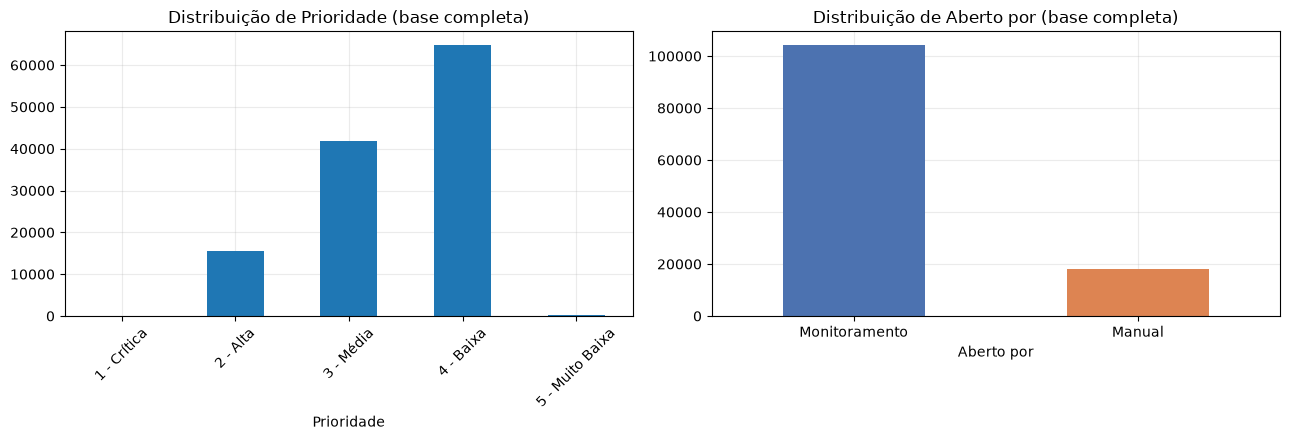

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

raw["Prioridade"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribuição de Prioridade (base completa)")
axes[0].tick_params(axis="x", rotation=45)

raw["Aberto por"].value_counts().plot(kind="bar", ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Distribuição de Aberto por (base completa)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

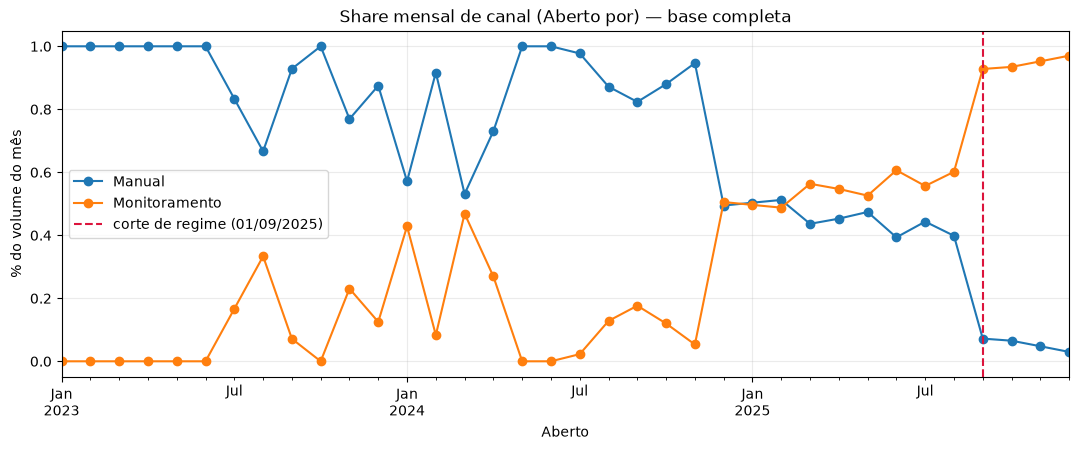

In [9]:
canal_mensal = (
    raw.set_index("Aberto")
    .groupby([pd.Grouper(freq="MS"), "Aberto por"])
    .size()
    .unstack(fill_value=0)
)
canal_share = canal_mensal.div(canal_mensal.sum(axis=1), axis=0)

fig, ax = plt.subplots()
canal_share.plot(ax=ax, marker="o")
ax.axvline(CORTE_REGIME, color="crimson", linestyle="--", label="corte de regime (01/09/2025)")
ax.set_title("Share mensal de canal (Aberto por) — base completa")
ax.set_ylabel("% do volume do mês")
ax.legend()
plt.show()

**Gráfico → insight → implicação**

- Volume mensal salta a partir de 2025 — dá para restringir a modelagem a esse ano sem perder
  incidentes representativos do processo atual.
- Prioridade, na base completa, é dominada por `4 - Baixa` — fora do escopo aqui; a população
  de modelagem (Seção 06) filtra só P2/P3.
- O share de Monitoramento cresce ao longo do tempo e ultrapassa Manual depois do corte de
  regime — a mesma mudança que derruba a categorização automática (Seção 04). Implicação:
  TRAIN e TEST não vão ter a mesma mistura de canal, o que precisa ser testado, não assumido
  (Seção 15).

Próximo passo: população de modelagem (P2/P3 + `Categoria` preenchida) e, a partir dela, o
split temporal.

## 06 — População de modelagem

A partir daqui, nenhuma etapa pode olhar dado que "aprende" antes do split acontecer — classes
raras, encoders, vetorizador de texto entram só depois (Seções 07 em diante).

População: `Prioridade` em {P2, P3} e `Categoria` preenchida. O que sobra — P2/P3 sem
`Categoria` — é o conjunto de aplicação real (Seção 19): é para esses incidentes que o modelo
teria valor prático hoje.

In [10]:
mask_pop = raw["Prioridade"].isin(["2 - Alta", "3 - Média"])
df_pop = raw[mask_pop].copy()

df_rotulado_full = df_pop[df_pop["Categoria"].notna()].copy()
df_aplicacao = df_pop[df_pop["Categoria"].isna()].copy()

print(f"P2/P3 total: {len(df_pop):,}")
print(f"P2/P3 com Categoria (rotulado, todos os anos): {len(df_rotulado_full):,}")
print(f"P2/P3 sem Categoria (aplicação futura): {len(df_aplicacao):,}")
print("Distribuição por ano do rotulado:")
print(df_rotulado_full["Aberto"].dt.year.value_counts().sort_index())

df_rotulado = df_rotulado_full[df_rotulado_full["Aberto"].dt.year == 2025].copy()
print(f"\nRotulado restrito a 2025 (usado na modelagem): {len(df_rotulado):,}")

P2/P3 total: 57,381
P2/P3 com Categoria (rotulado, todos os anos): 35,028
P2/P3 sem Categoria (aplicação futura): 22,353
Distribuição por ano do rotulado:
Aberto
2023       90
2024      386
2025    34552
Name: count, dtype: int64

Rotulado restrito a 2025 (usado na modelagem): 34,552


98,6% da população rotulada é de 2025. Restringir a modelagem a esse ano descarta pouco e
evita misturar processo de anos anteriores, que de qualquer forma não têm partição contígua de
split disponível.

## 07 — Split temporal

TRAIN = jan-ago/2025, VAL = set/2025, TEST = out-dez/2025, sem embaralhar. A ideia é simples:
treinar só com o passado e validar contra o futuro, do jeito que o modelo vai ser usado de
verdade — nunca vendo, no treino, um dado que só existiria depois da data em que o incidente
foi aberto. A partir daqui, esse split acontece antes de qualquer classe rara, encoder ou
vetorizador de texto ser ajustado (Seções 08-11).

In [11]:
train = df_rotulado[(df_rotulado["Aberto"] >= "2025-01-01") & (df_rotulado["Aberto"] < "2025-09-01")].copy()
val   = df_rotulado[(df_rotulado["Aberto"] >= "2025-09-01") & (df_rotulado["Aberto"] < "2025-10-01")].copy()
test  = df_rotulado[(df_rotulado["Aberto"] >= "2025-10-01") & (df_rotulado["Aberto"] < "2026-01-01")].copy()

for _df in (train, val, test):
    _df["Produto"] = _df["Produto"].fillna("Desconhecido")
    _df["Item de configuração"] = _df["Item de configuração"].fillna("Desconhecido")
    _df["Descrição resumida"] = _df["Descrição resumida"].fillna("")

print(f"TRAIN: {len(train):,} | categorias distintas: {train['Categoria'].nunique()}")
print(f"VAL:   {len(val):,} | categorias distintas: {val['Categoria'].nunique()}")
print(f"TEST:  {len(test):,} | categorias distintas: {test['Categoria'].nunique()}")
assert len(train) + len(val) + len(test) == len(df_rotulado)

TRAIN: 21,479 | categorias distintas: 125
VAL:   4,230 | categorias distintas: 76
TEST:  8,843 | categorias distintas: 105


In [12]:
cat_train, cat_val, cat_test = set(train["Categoria"]), set(val["Categoria"]), set(test["Categoria"])
novas_val, novas_test = cat_val - cat_train, cat_test - cat_train
invisiveis = cat_train - cat_val - cat_test

print("Categorias novas em VAL (fora do TRAIN):", len(novas_val),
      "-> registros afetados:", val["Categoria"].isin(novas_val).sum())
print("Categorias novas em TEST (fora do TRAIN):", len(novas_test),
      "-> registros afetados:", test["Categoria"].isin(novas_test).sum())
print("Categorias do TRAIN nunca vistas em VAL nem TEST:", len(invisiveis))

print("\nComposição de canal por partição:")
for nome, part in [("TRAIN", train), ("VAL", val), ("TEST", test)]:
    print(f"  {nome}: {part['Aberto por'].value_counts(normalize=True).round(3).to_dict()}")

print("\nTop 10 categorias do TRAIN (share do volume):")
top10_share = train["Categoria"].value_counts(normalize=True).head(10)
print(top10_share.round(4))
print("soma top10:", round(top10_share.sum(), 4))

Categorias novas em VAL (fora do TRAIN): 4 -> registros afetados: 5
Categorias novas em TEST (fora do TRAIN): 8 -> registros afetados: 11
Categorias do TRAIN nunca vistas em VAL nem TEST: 25

Composição de canal por partição:
  TRAIN: {'Manual': 0.562, 'Monitoramento': 0.438}
  VAL: {'Monitoramento': 0.645, 'Manual': 0.355}
  TEST: {'Monitoramento': 0.639, 'Manual': 0.361}

Top 10 categorias do TRAIN (share do volume):
Categoria
cat85    0.133
cat71    0.116
cat76    0.110
cat31    0.081
cat77    0.056
cat137   0.047
cat73    0.045
cat91    0.043
cat103   0.024
cat18    0.023
Name: proportion, dtype: float64
soma top10: 0.6758


**Resultado do split:** 4 categorias aparecem em VAL e 8 em TEST sem nunca terem aparecido no
TRAIN — poucos registros afetados (5 e 11), mas o suficiente para mostrar que o modelo vai
encontrar categoria desconhecida em produção. Tratamento: qualquer categoria fora do
vocabulário do TRAIN vira `OUTRAS_RARAS`, nunca gera erro.

No sentido inverso, 25 das 125 categorias do TRAIN nunca aparecem em VAL nem TEST — quase 20%
das classes ficam sem como validar o recall individual (retomado na Seção 18).

O canal de abertura também muda: Manual cai de 56,2% no TRAIN para ~36% em VAL/TEST. É por
isso que `Aberto por` entra como candidato a feature, não como certeza — testado com e sem no
pipeline final (Seção 15).

## 08 — Classes raras: qual corte usar?

**Teste:** comparar cortes de 10, 20, 30 e 50 exemplos mínimos por categoria no TRAIN, cada um
agrupado em `OUTRAS_RARAS`, com um pipeline simples (TF-IDF básico + one-hot de
Prioridade/Produto + Regressão Logística) avaliado em VAL.

In [13]:
counts_train = train["Categoria"].value_counts()

print("Volume afetado por corte (calculado só no TRAIN):")
for corte in [10, 20, 30, 50]:
    raras = counts_train[counts_train < corte]
    principais = counts_train[counts_train >= corte]
    print(f"  corte<{corte}: agrupadas={len(raras):3d}  principais={len(principais):3d}  "
          f"%volume_train={raras.sum() / counts_train.sum():.1%}")

Volume afetado por corte (calculado só no TRAIN):
  corte<10: agrupadas= 57  principais= 68  %volume_train=0.9%
  corte<20: agrupadas= 69  principais= 56  %volume_train=1.7%
  corte<30: agrupadas= 74  principais= 51  %volume_train=2.2%
  corte<50: agrupadas= 80  principais= 45  %volume_train=3.3%


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from scipy.sparse import hstack

def aplicar_raras(y, raras_set, cats_treino):
    """Mapeia para OUTRAS_RARAS: (a) categorias raras do TRAIN, (b) qualquer categoria
    desconhecida do TRAIN (cold-start em VAL/TEST). Mapeamento fixo, nunca recalculado fora do TRAIN."""
    y = y.where(~y.isin(raras_set), "OUTRAS_RARAS")
    y = y.where(y.isin(cats_treino) | (y == "OUTRAS_RARAS"), "OUTRAS_RARAS")
    return y

_tfidf_sonda = TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 1))
_Xtxt_tr = _tfidf_sonda.fit_transform(train["Descrição resumida"])
_Xtxt_val = _tfidf_sonda.transform(val["Descrição resumida"])
_ohe_sonda = OneHotEncoder(handle_unknown="ignore")
_Xcat_tr = _ohe_sonda.fit_transform(train[["Prioridade", "Produto"]])
_Xcat_val = _ohe_sonda.transform(val[["Prioridade", "Produto"]])
_Xtr_sonda = hstack([_Xtxt_tr, _Xcat_tr]).tocsr()
_Xval_sonda = hstack([_Xtxt_val, _Xcat_val]).tocsr()

resultados_corte = []
for corte in [10, 20, 30, 50]:
    raras_set = set(counts_train[counts_train < corte].index)
    cats_treino = set(counts_train.index) - raras_set
    y_tr_c = aplicar_raras(train["Categoria"], raras_set, cats_treino)
    y_val_c = aplicar_raras(val["Categoria"], raras_set, cats_treino)
    clf = LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(_Xtr_sonda, y_tr_c)
    pred = clf.predict(_Xval_sonda)
    f1m = f1_score(y_val_c, pred, average="macro")
    f1w = f1_score(y_val_c, pred, average="weighted")
    resultados_corte.append({"corte": corte, "n_raras": len(raras_set), "f1_macro": f1m, "f1_weighted": f1w})
    print(f"corte<{corte}: n_classes_agrupadas={len(raras_set):3d}  F1-Macro={f1m:.4f}  F1-Weighted={f1w:.4f}")

CORTE_ESCOLHIDO = max(resultados_corte, key=lambda r: r["f1_macro"])["corte"]
print(f"\nCorte escolhido (maior F1-Macro em VAL): < {CORTE_ESCOLHIDO}")

corte<10: n_classes_agrupadas= 57  F1-Macro=0.5789  F1-Weighted=0.7558


corte<20: n_classes_agrupadas= 69  F1-Macro=0.6393  F1-Weighted=0.7673


corte<30: n_classes_agrupadas= 74  F1-Macro=0.6398  F1-Weighted=0.7685


corte<50: n_classes_agrupadas= 80  F1-Macro=0.6728  F1-Weighted=0.7712

Corte escolhido (maior F1-Macro em VAL): < 50


**Resultado:** F1-Macro sobe conforme o corte fica mais agressivo — `< 50` é o melhor dos
quatro testados.

**Interpretação:** ~20% das categorias do TRAIN nunca aparecem em VAL (Seção 07) — modelar
essas classes finas desperdiça capacidade em rótulos que não têm como ser validados. Agrupar
estabiliza a métrica sem custo real: só 3,3% do volume do TRAIN muda de rótulo.

**Decisão:** corte `< 50`, reaproveitado em toda a modelagem daqui em diante.

In [15]:
RARAS_SET = set(counts_train[counts_train < CORTE_ESCOLHIDO].index)
CATS_TREINO = set(counts_train.index) - RARAS_SET

def aplicar_corte_final(y):
    return aplicar_raras(y, RARAS_SET, CATS_TREINO)

y_train = aplicar_corte_final(train["Categoria"])
y_val = aplicar_corte_final(val["Categoria"])
y_test = aplicar_corte_final(test["Categoria"])

# alvo sem nenhum agrupamento (só cold-start vira OUTRAS_RARAS) -- usado no Experimento 10 (Etapa 15)
cats_vistas_treino = set(train["Categoria"].unique())
y_train_raw = train["Categoria"].copy()
y_val_raw = val["Categoria"].where(val["Categoria"].isin(cats_vistas_treino), "OUTRAS_RARAS")
y_test_raw = test["Categoria"].where(test["Categoria"].isin(cats_vistas_treino), "OUTRAS_RARAS")

print(f"Classes finais no TRAIN (com agrupamento < {CORTE_ESCOLHIDO}): {y_train.nunique()}")
print(f"Classes no TRAIN sem agrupamento: {y_train_raw.nunique()}")

Classes finais no TRAIN (com agrupamento < 50): 46
Classes no TRAIN sem agrupamento: 125


## 09 — Preparação: nulos e leakage

Regra prática: se a informação não estivesse disponível no momento da abertura, ela não pode
virar feature. É por isso que `Status`, `Solução`, `Duração` e o resto de `COLUNAS_LEAKAGE`
(Seção 02) ficam de fora — confirmado por `assert`, não por promessa. Nulos de `Produto` e
`Item de configuração` já foram preenchidos com `"Desconhecido"` junto do split (Seção 07).

In [16]:
FEATURE_COLS_PERMITIDAS = {"Prioridade", "Produto", "Item de configuração", "Aberto",
                            "Descrição resumida", "Aberto por"}
assert FEATURE_COLS_PERMITIDAS.isdisjoint(COLUNAS_LEAKAGE), "Coluna de leakage entrou na lista de features permitidas!"
assert train["Produto"].isna().sum() == 0 and train["Item de configuração"].isna().sum() == 0
assert val["Produto"].isna().sum() == 0 and test["Produto"].isna().sum() == 0
print("Nenhuma coluna de leakage nas features permitidas. Nulos de Produto/Item de configuração tratados.")
print("Colunas permitidas como feature:", sorted(FEATURE_COLS_PERMITIDAS))

Nenhuma coluna de leakage nas features permitidas. Nulos de Produto/Item de configuração tratados.
Colunas permitidas como feature: ['Aberto', 'Aberto por', 'Descrição resumida', 'Item de configuração', 'Prioridade', 'Produto']


## 10 — Features categóricas

Regra única: encoder ajustado (`fit`) só no TRAIN, aplicado (`transform`) em VAL/TEST.

- `Prioridade` e `Produto`: one-hot direto — `Produto` é o preditor estrutural mais forte
  medido até aqui, bem acima de `Aberto por`.
- `Aberto por`: entra por padrão, mas a remoção é testada mais adiante (Seção 15) — o mix de
  canal muda demais entre TRAIN e TEST (Seção 07) para confiar nela de saída.
- `Item de configuração`: mais da metade dos valores do TRAIN aparece uma única vez — one-hot
  direto viraria ruído. Os valores raros são agrupados num bucket e representados como
  frequência (não one-hot), para não explodir a dimensão da matriz.
- `Grupo designado`: fora do pipeline — não dá para confirmar, só com a base, que a atribuição
  acontece no momento da abertura (Seção 04).

In [17]:
ic_counts_train = train["Item de configuração"].value_counts()
IC_KEPT = set(ic_counts_train[ic_counts_train >= 5].index)
print(f"Item de configuração -- valores mantidos (>=5 ocorrências no TRAIN): {len(IC_KEPT)} de {len(ic_counts_train)}")

def bucket_ic(s):
    """Qualquer valor fora do vocabulário aprendido no TRAIN (raro ou nunca visto) vira RARO."""
    return s.where(s.isin(IC_KEPT), "RARO")

for _df in (train, val, test):
    _df["_ic_bucket"] = bucket_ic(_df["Item de configuração"])

ic_freq_map = train["_ic_bucket"].value_counts().to_dict()
ic_freq_default = ic_freq_map.get("RARO", 1)

def ic_freq_feature(d):
    return np.log1p(d["_ic_bucket"].map(ic_freq_map).fillna(ic_freq_default).values).reshape(-1, 1)

print("Distribuição do bucket em VAL (top 5):")
print(val["_ic_bucket"].value_counts(normalize=True).head())

Item de configuração -- valores mantidos (>=5 ocorrências no TRAIN): 660 de 3898
Distribuição do bucket em VAL (top 5):
_ic_bucket
RARO      0.523
IC00349   0.065
IC00725   0.035
IC00604   0.025
IC01285   0.012
Name: proportion, dtype: float64


In [18]:
from scipy.sparse import csr_matrix

def build_estruturado(d_fit, d_list, incluir_canal=True):
    """Ajusta encoders só em d_fit (TRAIN) e transforma cada dataframe de d_list."""
    cat_cols = ["Prioridade", "Produto"] + (["Aberto por"] if incluir_canal else [])
    ohe = OneHotEncoder(handle_unknown="ignore")
    ohe.fit(d_fit[cat_cols])
    saidas = []
    for d in d_list:
        Xcat = ohe.transform(d[cat_cols])
        saidas.append(hstack([Xcat, csr_matrix(ic_freq_feature(d))]).tocsr())
    return saidas, ohe

(Xs_tr, Xs_val, Xs_test), ohe_estrutural = build_estruturado(train, [train, val, test], incluir_canal=True)
print("Matriz estruturada (com canal):", Xs_tr.shape, Xs_val.shape, Xs_test.shape)

Matriz estruturada (com canal): (21479, 52) (4230, 52) (8843, 52)


## 11 — Texto: TF-IDF

`Descrição resumida` é a única fonte de texto livre disponível na abertura. Em vez de fixar os
parâmetros do TF-IDF por suposição, uma varredura controlada de `ngram_range` × `min_df` ×
`max_features` decide a configuração em VAL. O vetorizador é sempre ajustado só no TRAIN.

In [19]:
sweep_resultados = []
for ngram in [(1, 1), (1, 2)]:
    for min_df in [2, 5]:
        for max_feat in [2000, 5000, None]:
            vec = TfidfVectorizer(ngram_range=ngram, min_df=min_df, max_features=max_feat)
            Xt = vec.fit_transform(train["Descrição resumida"])
            Xv = vec.transform(val["Descrição resumida"])
            clf = LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE)
            clf.fit(Xt, y_train)
            pred = clf.predict(Xv)
            f1m = f1_score(y_val, pred, average="macro")
            sweep_resultados.append({"ngram_range": ngram, "min_df": min_df,
                                      "max_features": max_feat, "n_features": Xt.shape[1], "f1_macro": f1m})

sweep_df = pd.DataFrame(sweep_resultados).sort_values("f1_macro", ascending=False)
sweep_df

,ngram_range,min_df,max_features,n_features,f1_macro
7,"(1, 2)",2,"5,000.000",5000,0.382
8,"(1, 2)",2,NaN,7751,0.380
1,"(1, 1)",2,"5,000.000",2801,0.372
2,"(1, 1)",2,NaN,2801,0.372
10,"(1, 2)",5,"5,000.000",3335,0.371
11,"(1, 2)",5,NaN,3335,0.371
0,"(1, 1)",2,"2,000.000",2000,0.367
3,"(1, 1)",5,"2,000.000",1278,0.365
4,"(1, 1)",5,"5,000.000",1278,0.365
5,"(1, 1)",5,NaN,1278,0.365


In [20]:
melhor_unigrama = sweep_df[sweep_df["ngram_range"] == (1, 1)].iloc[0]
melhor_geral = sweep_df.iloc[0]
margem_relativa = (melhor_geral["f1_macro"] - melhor_unigrama["f1_macro"]) / melhor_unigrama["f1_macro"]
print(f"Melhor config geral: {melhor_geral.to_dict()}")
print(f"Melhor unigrama:     {melhor_unigrama.to_dict()}")
print(f"Margem relativa do bigrama sobre o unigrama: {margem_relativa:.1%}")

# critério de parada do Plano 2 (seção 4.2): só troca para (1,2) se a margem for clara.
# ~2,7% de ganho relativo não é uma margem clara -> fica com o unigrama (menos dimensão, mais simples de explicar).
TFIDF_NGRAM = (1, 1)
TFIDF_MIN_DF = int(melhor_unigrama["min_df"])
TFIDF_MAX_FEATURES = None if pd.isna(melhor_unigrama["max_features"]) else int(melhor_unigrama["max_features"])
print(f"\nConfig escolhida: ngram={TFIDF_NGRAM}, min_df={TFIDF_MIN_DF}, max_features={TFIDF_MAX_FEATURES}")

Melhor config geral: {'ngram_range': (1, 2), 'min_df': 2, 'max_features': 5000.0, 'n_features': 5000, 'f1_macro': 0.381936218294349}
Melhor unigrama:     {'ngram_range': (1, 1), 'min_df': 2, 'max_features': 5000.0, 'n_features': 2801, 'f1_macro': 0.37204530347043213}
Margem relativa do bigrama sobre o unigrama: 2.7%

Config escolhida: ngram=(1, 1), min_df=2, max_features=5000


**Resultado:** bigrama supera unigrama por ~2,7% relativo de F1-Macro — dentro da faixa que
se trata como ruído, não como vantagem real.

**Decisão:** unigrama, `min_df=2`, `max_features=5000` — menos da metade das colunas do
bigrama, sem perda prática de desempenho e mais fácil de explicar.

In [21]:
vec_final = TfidfVectorizer(ngram_range=TFIDF_NGRAM, min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
Xt_tr = vec_final.fit_transform(train["Descrição resumida"])
Xt_val = vec_final.transform(val["Descrição resumida"])
Xt_test = vec_final.transform(test["Descrição resumida"])
print("Matriz de texto (TF-IDF final):", Xt_tr.shape, Xt_val.shape, Xt_test.shape)

Xh_tr = hstack([Xt_tr, Xs_tr]).tocsr()
Xh_val = hstack([Xt_val, Xs_val]).tocsr()
Xh_test = hstack([Xt_test, Xs_test]).tocsr()
print("Matriz híbrida (texto + estruturado, com canal):", Xh_tr.shape, Xh_val.shape, Xh_test.shape)

Matriz de texto (TF-IDF final): (21479, 2801) (4230, 2801) (8843, 2801)
Matriz híbrida (texto + estruturado, com canal): (21479, 2853) (4230, 2853) (8843, 2853)


## 12 — Vale a pena usar hora/dia/mês?

Mesma disciplina de sempre: medir associação com `Categoria` no TRAIN antes de considerar
qualquer coisa mais elaborada, como codificação cíclica seno/cosseno.

In [22]:
from sklearn.metrics import normalized_mutual_info_score

hora = train["Aberto"].dt.hour.astype(str)
dow = train["Aberto"].dt.dayofweek.astype(str)
mes = train["Aberto"].dt.month.astype(str)
fds = (train["Aberto"].dt.dayofweek >= 5).astype(str)

print("NMI com Categoria, calculado no TRAIN:")
for nome, s in [("hora", hora), ("dia_semana", dow), ("mês", mes), ("fim_de_semana", fds)]:
    nmi = normalized_mutual_info_score(s, train["Categoria"])
    print(f"  {nome}: {nmi:.4f}")

NMI com Categoria, calculado no TRAIN:
  hora: 0.0759
  dia_semana: 0.0279
  mês: 0.0399
  fim_de_semana: 0.0199


**Resultado:** NMI baixo (0,02–0,08) — bem abaixo de `Produto` ou até `Aberto por`.

**Interpretação:** sinal fraco, mas a decisão de incluir ou não só é tomada com o modelo de
verdade (Experimento 9, Seção 15) — NMI é indício, não veredito.

**Adiantando o resultado:** o teste empírico confirma o que o NMI já sugeria — features
temporais não ajudam.

## 13 — Baselines: o modelo aprende algo além de regra simples?

Três baselines sem nenhum aprendizado real, avaliados no mesmo alvo agrupado usado pelo resto
do notebook — a régua para saber se a modelagem vale a complexidade.

1. Categoria mais frequente global.
2. Categoria mais frequente por `Produto` (fallback: moda global).
3. Top-3 categorias mais frequentes por `Produto` (mede Top-3 Accuracy).

In [23]:
from sklearn.metrics import accuracy_score, top_k_accuracy_score

moda_global = y_train.mode()[0]
pred_base1 = pd.Series(moda_global, index=y_val.index)
print("Baseline 1 (moda global):")
print(f"  Accuracy={accuracy_score(y_val, pred_base1):.4f}  "
      f"F1-Macro={f1_score(y_val, pred_base1, average='macro'):.4f}  "
      f"F1-Weighted={f1_score(y_val, pred_base1, average='weighted'):.4f}")

Baseline 1 (moda global):
  Accuracy=0.0605  F1-Macro=0.0025  F1-Weighted=0.0069


In [24]:
moda_por_produto = train.assign(_y=y_train).groupby("Produto")["_y"].agg(lambda s: s.mode()[0])
pred_base2 = val["Produto"].map(moda_por_produto).fillna(moda_global)
acc2 = accuracy_score(y_val, pred_base2)
f1m2 = f1_score(y_val, pred_base2, average="macro")
f1w2 = f1_score(y_val, pred_base2, average="weighted")
n_cats_previstas = pred_base2.nunique()
print("Baseline 2 (moda por Produto):")
print(f"  Accuracy={acc2:.4f}  F1-Macro={f1m2:.4f}  F1-Weighted={f1w2:.4f}")
print(f"  Categorias distintas que esse baseline consegue prever: {n_cats_previstas} "
      f"(de {y_val.nunique()} presentes em VAL)")

Baseline 2 (moda por Produto):
  Accuracy=0.5220  F1-Macro=0.2681  F1-Weighted=0.4518
  Categorias distintas que esse baseline consegue prever: 21 (de 46 presentes em VAL)


In [25]:
top3_por_produto = train.assign(_y=y_train).groupby("Produto")["_y"].agg(lambda s: list(s.value_counts().head(3).index))
_val_tmp = val.assign(_y_true=y_val.values)
_val_tmp["_hit"] = _val_tmp.apply(
    lambda row: row["_y_true"] in top3_por_produto.get(row["Produto"], [moda_global]), axis=1)
top3_baseline2b = _val_tmp["_hit"].mean()
print(f"Baseline 2b (Top-3 por Produto): Top-3 Accuracy={top3_baseline2b:.4f}")

Baseline 2b (Top-3 por Produto): Top-3 Accuracy=0.8506


**Resultado:** o Baseline 2 (moda por Produto) chega perto da meta de Accuracy sozinho — mas
com F1-Macro bem mais baixo, porque só consegue prever uma categoria por Produto, ignorando
toda categoria minoritária.

**Interpretação:** é a prova de que Accuracy sozinha engana neste problema — dá para acertar a
maioria dos casos comuns e ainda assim falhar estruturalmente nas classes raras. F1-Macro é a
métrica que decide os experimentos daqui em diante, não Accuracy.

## 14 — Qual família de modelo?

Árvores (Random Forest, CatBoost) não lidam bem com uma matriz TF-IDF esparsa de milhares de
colunas — por isso só entram na família estruturada, de dimensão baixa.

- **Texto**: TF-IDF → Logistic Regression, Linear SVM.
- **Estruturado**: categóricas → Logistic Regression, Random Forest, CatBoost.
- **Híbrido**: texto + estruturado → Logistic Regression, Linear SVM.

Todos usam o alvo agrupado (Seção 08) e a matriz estruturada com canal — a decisão de manter ou
remover o canal é isolada depois (Seção 15).

In [26]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

def avaliar(nome, clf, Xval, yval):
    pred = clf.predict(Xval)
    f1m = f1_score(yval, pred, average="macro")
    f1w = f1_score(yval, pred, average="weighted")
    acc = accuracy_score(yval, pred)
    try:
        score = clf.predict_proba(Xval) if hasattr(clf, "predict_proba") else clf.decision_function(Xval)
        top3 = top_k_accuracy_score(yval, score, k=3, labels=clf.classes_)
    except (ValueError, AttributeError):
        top3 = np.nan
    r = {"modelo": nome, "accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w, "top3": top3}
    print(f"{nome:20s} acc={acc:.4f}  F1-Macro={f1m:.4f}  F1-Weighted={f1w:.4f}  Top3={top3:.4f}")
    return r

resultados_familias = []

In [27]:
# Família A -- texto
clf = LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE).fit(Xt_tr, y_train)
resultados_familias.append(avaliar("A1_texto_LR", clf, Xt_val, y_val))

clf = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE).fit(Xt_tr, y_train)
resultados_familias.append(avaliar("A2_texto_SVM", clf, Xt_val, y_val))

A1_texto_LR          acc=0.4891  F1-Macro=0.3720  F1-Weighted=0.5281  Top3=0.7040


A2_texto_SVM         acc=0.4858  F1-Macro=0.3920  F1-Weighted=0.5331  Top3=0.6934


In [28]:
# Família B -- estruturado
clf = LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE).fit(Xs_tr, y_train)
resultados_familias.append(avaliar("B1_estrut_LR", clf, Xs_val, y_val))

clf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1).fit(Xs_tr, y_train)
resultados_familias.append(avaliar("B2_estrut_RF", clf, Xs_val, y_val))

clf = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, loss_function="MultiClass",
                          auto_class_weights="Balanced", random_state=RANDOM_STATE, verbose=False)
clf.fit(Xs_tr, y_train)
_pred = clf.predict(Xs_val).ravel()
_proba = clf.predict_proba(Xs_val)
_r = {"modelo": "B3_estrut_CatBoost", "accuracy": accuracy_score(y_val, _pred),
      "f1_macro": f1_score(y_val, _pred, average="macro"), "f1_weighted": f1_score(y_val, _pred, average="weighted"),
      "top3": top_k_accuracy_score(y_val, _proba, k=3, labels=clf.classes_.ravel())}
print(f"B3_estrut_CatBoost   acc={_r['accuracy']:.4f}  F1-Macro={_r['f1_macro']:.4f}  "
      f"F1-Weighted={_r['f1_weighted']:.4f}  Top3={_r['top3']:.4f}")
resultados_familias.append(_r)

B1_estrut_LR         acc=0.4638  F1-Macro=0.4384  F1-Weighted=0.4846  Top3=0.8920


B2_estrut_RF         acc=0.5473  F1-Macro=0.5201  F1-Weighted=0.5732  Top3=0.9388


B3_estrut_CatBoost   acc=0.5567  F1-Macro=0.5213  F1-Weighted=0.5862  Top3=0.9369


In [29]:
# Família C -- híbrido
clf = LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE).fit(Xh_tr, y_train)
resultados_familias.append(avaliar("C1_hibrido_LR", clf, Xh_val, y_val))

clf = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE).fit(Xh_tr, y_train)
resultados_familias.append(avaliar("C2_hibrido_SVM", clf, Xh_val, y_val))

C1_hibrido_LR        acc=0.7447  F1-Macro=0.6661  F1-Weighted=0.7632  Top3=0.9700


C2_hibrido_SVM       acc=0.8366  F1-Macro=0.7213  F1-Weighted=0.8417  Top3=0.9645


In [30]:
df_familias = pd.DataFrame(resultados_familias).sort_values("f1_macro", ascending=False)
df_familias

,modelo,accuracy,f1_macro,f1_weighted,top3
6,C2_hibrido_SVM,0.837,0.721,0.842,0.965
5,C1_hibrido_LR,0.745,0.666,0.763,0.970
4,B3_estrut_CatBoost,0.557,0.521,0.586,0.937
3,B2_estrut_RF,0.547,0.520,0.573,0.939
2,B1_estrut_LR,0.464,0.438,0.485,0.892
1,A2_texto_SVM,0.486,0.392,0.533,0.693
0,A1_texto_LR,0.489,0.372,0.528,0.704


**Resultado:** o híbrido supera texto puro e estrutura pura por larga margem — as duas fontes
de sinal se somam, não se sobrepõem. `Produto` sozinho já carrega mais sinal que a descrição
sozinha, mas é a combinação que destrava o salto de desempenho.

**Interpretação:** a meta de Accuracy já é batida antes de qualquer tuning — sinal de que o
ganho vem do desenho do pipeline, não de ajuste fino de hiperparâmetro.

**Decisão:** pipeline vencedor = híbrido (TF-IDF + estruturado, com canal) → Linear SVM. Segue
para os experimentos incrementais.

## 15 — Ajustando o pipeline vencedor

A partir daqui, cada experimento muda uma coisa só, sempre lido em VAL, para isolar o que
realmente move o F1-Macro:

- features temporais entram ou não?
- classes raras ficam agrupadas ou não?
- o canal de abertura fica ou sai?

In [31]:
def treinar_avaliar_svm(nome, Xtr, ytr, Xval, yval):
    clf = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000).fit(Xtr, ytr)
    pred = clf.predict(Xval)
    f1m = f1_score(yval, pred, average="macro")
    f1w = f1_score(yval, pred, average="weighted")
    acc = accuracy_score(yval, pred)
    try:
        top3 = top_k_accuracy_score(yval, clf.decision_function(Xval), k=3, labels=clf.classes_)
    except ValueError:
        top3 = np.nan
    r = {"experimento": nome, "accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w, "top3": top3}
    print(f"{nome:28s} acc={acc:.4f}  F1-Macro={f1m:.4f}  F1-Weighted={f1w:.4f}  Top3={top3}")
    return r

resultados_incrementais = [treinar_avaliar_svm("baseline_winner_C2", Xh_tr, y_train, Xh_val, y_val)]

baseline_winner_C2           acc=0.8366  F1-Macro=0.7213  F1-Weighted=0.8417  Top3=0.9645390070921985


In [32]:
# Experimento 9: + features temporais (hora/dia da semana/mês, one-hot)
def tcols(d):
    return pd.DataFrame({"hora": d["Aberto"].dt.hour.astype(str),
                          "dow": d["Aberto"].dt.dayofweek.astype(str),
                          "mes": d["Aberto"].dt.month.astype(str)})

ohe_temporal = OneHotEncoder(handle_unknown="ignore").fit(tcols(train))
Xs_tr_T = hstack([Xs_tr, ohe_temporal.transform(tcols(train))]).tocsr()
Xs_val_T = hstack([Xs_val, ohe_temporal.transform(tcols(val))]).tocsr()
Xh_tr_T = hstack([Xt_tr, Xs_tr_T]).tocsr()
Xh_val_T = hstack([Xt_val, Xs_val_T]).tocsr()

resultados_incrementais.append(treinar_avaliar_svm("exp09_com_temporal", Xh_tr_T, y_train, Xh_val_T, y_val))

exp09_com_temporal           acc=0.8168  F1-Macro=0.6931  F1-Weighted=0.8253  Top3=0.9647754137115839


In [33]:
# Experimento 10: alvo sem agrupamento de classes raras (só cold-start vira OUTRAS_RARAS)
resultados_incrementais.append(treinar_avaliar_svm("exp10_labels_sem_agrupar", Xh_tr, y_train_raw, Xh_val, y_val_raw))

exp10_labels_sem_agrupar     acc=0.8210  F1-Macro=0.5346  F1-Weighted=0.8329  Top3=nan


In [34]:
# Experimento 11 (com Aberto por) já é o baseline acima; Experimento 12: sem Aberto por
(Xs_tr_noC, Xs_val_noC, Xs_test_noC), _ = build_estruturado(train, [train, val, test], incluir_canal=False)
Xh_tr_noC = hstack([Xt_tr, Xs_tr_noC]).tocsr()
Xh_val_noC = hstack([Xt_val, Xs_val_noC]).tocsr()
Xh_test_noC = hstack([Xt_test, Xs_test_noC]).tocsr()

r11 = dict(resultados_incrementais[0]); r11["experimento"] = "exp11_com_aberto_por"
resultados_incrementais.append(r11)
resultados_incrementais.append(treinar_avaliar_svm("exp12_sem_aberto_por", Xh_tr_noC, y_train, Xh_val_noC, y_val))

exp12_sem_aberto_por         acc=0.8392  F1-Macro=0.7286  F1-Weighted=0.8441  Top3=0.9635933806146572


In [35]:
df_incrementais = pd.DataFrame(resultados_incrementais)
df_incrementais

,experimento,accuracy,f1_macro,f1_weighted,top3
0,baseline_winner_C2,0.837,0.721,0.842,0.965
1,exp09_com_temporal,0.817,0.693,0.825,0.965
2,exp10_labels_sem_agrupar,0.821,0.535,0.833,NaN
3,exp11_com_aberto_por,0.837,0.721,0.842,0.965
4,exp12_sem_aberto_por,0.839,0.729,0.844,0.964


**Experimento 9 — features temporais:** pioram o F1-Macro. Confirma o NMI baixo da Seção 12.
**Fora do pipeline.**

**Experimento 10 — sem agrupar classes raras:** F1-Macro despenca, enquanto Accuracy quase não
muda — o mesmo padrão do Baseline 2 (Seção 13), agora dentro do próprio modelo. Confirma a
Seção 08: **`OUTRAS_RARAS` fica.**

**Experimentos 11/12 — canal de abertura:** removê-lo não piora — melhora ligeiramente.
Confirma a cautela da Seção 07 sobre o mix de canal mudar entre TRAIN e TEST. **`Aberto por`
sai do pipeline final.**

**Pipeline final:** TF-IDF (unigrama) + estruturado (Prioridade, Produto, frequência de Item
de configuração, sem canal, sem temporais) → Linear SVM, alvo agrupado.

## 16 — Tuning

Só o pipeline vencedor é ajustado — Random Search leve sobre `C` e `class_weight`, os únicos
hiperparâmetros relevantes de um Linear SVM.

In [36]:
tuning_resultados = []
for C in [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]:
    for cw in ["balanced", None]:
        clf = LinearSVC(C=C, class_weight=cw, random_state=RANDOM_STATE, max_iter=5000)
        clf.fit(Xh_tr_noC, y_train)
        pred = clf.predict(Xh_val_noC)
        tuning_resultados.append({
            "C": C, "class_weight": str(cw),
            "accuracy": accuracy_score(y_val, pred),
            "f1_macro": f1_score(y_val, pred, average="macro"),
            "f1_weighted": f1_score(y_val, pred, average="weighted"),
        })

df_tuning = pd.DataFrame(tuning_resultados).sort_values("f1_macro", ascending=False)
df_tuning

,C,class_weight,accuracy,f1_macro,f1_weighted
6,1.000,balanced,0.839,0.729,0.844
8,3.000,balanced,0.837,0.723,0.842
10,10.000,balanced,0.834,0.706,0.838
7,1.000,None,0.812,0.703,0.806
5,0.300,None,0.809,0.696,0.802
9,3.000,None,0.808,0.696,0.803
4,0.300,balanced,0.811,0.694,0.810
11,10.000,None,0.805,0.690,0.800
3,0.100,None,0.805,0.684,0.794
2,0.100,balanced,0.806,0.682,0.806


In [37]:
MELHOR_C = df_tuning.iloc[0]["C"]
MELHOR_CLASS_WEIGHT = None if df_tuning.iloc[0]["class_weight"] == "None" else df_tuning.iloc[0]["class_weight"]
print(f"Melhor configuração: C={MELHOR_C}, class_weight={MELHOR_CLASS_WEIGHT} "
      f"(F1-Macro={df_tuning.iloc[0]['f1_macro']:.4f} em VAL)")

Melhor configuração: C=1.0, class_weight=balanced (F1-Macro=0.7286 em VAL)


**Resultado:** os valores já usados por padrão (`C=1,0`, `class_weight="balanced"`) seguem
sendo os melhores.

**Interpretação:** tuning não é onde está o ganho neste problema — a escolha de features e o
agrupamento de classes raras já capturaram a maior parte do sinal disponível.

## 17 — TEST: a única leitura

Primeira e única vez que o TEST é consultado — nada até aqui usou TEST para escolher feature,
modelo, corte ou hiperparâmetro. Treinado só no TRAIN, para manter a mesma base de comparação
das etapas anteriores; o modelo de produção (Seção 19) retreina com TRAIN+VAL.

In [38]:
modelo_final_val = LinearSVC(C=MELHOR_C, class_weight=MELHOR_CLASS_WEIGHT,
                              random_state=RANDOM_STATE, max_iter=5000)
modelo_final_val.fit(Xh_tr_noC, y_train)

pred_test = modelo_final_val.predict(Xh_test_noC)
score_test = modelo_final_val.decision_function(Xh_test_noC)

acc_test = accuracy_score(y_test, pred_test)
f1m_test = f1_score(y_test, pred_test, average="macro")
f1w_test = f1_score(y_test, pred_test, average="weighted")
try:
    top3_test = top_k_accuracy_score(y_test, score_test, k=3, labels=modelo_final_val.classes_)
except ValueError:
    top3_test = np.nan

tabela_final = pd.DataFrame([
    {"Modelo": "Baseline1_moda_global", "Features": "-", "Accuracy": accuracy_score(y_val, pred_base1),
     "F1-Macro": f1_score(y_val, pred_base1, average="macro"), "F1-Weighted": f1_score(y_val, pred_base1, average="weighted"), "Top3": np.nan},
    {"Modelo": "Baseline2_moda_por_produto", "Features": "Produto", "Accuracy": acc2,
     "F1-Macro": f1m2, "F1-Weighted": f1w2, "Top3": np.nan},
    {"Modelo": "Winner (VAL)", "Features": "TF-IDF+estrut (sem canal)", "Accuracy": df_tuning.iloc[0]["accuracy"],
     "F1-Macro": df_tuning.iloc[0]["f1_macro"], "F1-Weighted": df_tuning.iloc[0]["f1_weighted"], "Top3": np.nan},
    {"Modelo": "Modelo final (TEST)", "Features": "TF-IDF+estrut (sem canal)", "Accuracy": acc_test,
     "F1-Macro": f1m_test, "F1-Weighted": f1w_test, "Top3": top3_test},
])
tabela_final

,Modelo,Features,Accuracy,F1-Macro,F1-Weighted,Top3
0,Baseline1_moda_global,-,0.061,0.002,0.007,NaN
1,Baseline2_moda_por_produto,Produto,0.522,0.268,0.452,NaN
2,Winner (VAL),TF-IDF+estrut (sem canal),0.839,0.729,0.844,NaN
3,Modelo final (TEST),TF-IDF+estrut (sem canal),0.808,0.695,0.810,0.952


In [39]:
print("Desempenho por mês dentro do TEST (out/nov/dez -- todo o TEST já é pós-regime):")
meses_test = test["Aberto"].dt.month
for mes, nome in [(10, "outubro"), (11, "novembro"), (12, "dezembro")]:
    m = (meses_test == mes).values
    print(f"  {nome:10s} (n={m.sum():4d}): Accuracy={accuracy_score(y_test[m], pred_test[m]):.4f}  "
          f"F1-Macro={f1_score(y_test[m], pred_test[m], average='macro'):.4f}")

Desempenho por mês dentro do TEST (out/nov/dez -- todo o TEST já é pós-regime):
  outubro    (n=3493): Accuracy=0.8225  F1-Macro=0.6789
  novembro   (n=3149): Accuracy=0.8469  F1-Macro=0.7130
  dezembro   (n=2201): Accuracy=0.7310  F1-Macro=0.6422


**Resultado:** meta de Accuracy batida com folga, com F1-Macro consistente com o que já era
visto em VAL — sem colapso surpresa no TEST. Dezembro é o mês mais fraco do trimestre: quanto
mais longe do fim do TRAIN, pior o desempenho, um padrão coerente com deriva temporal natural,
não com erro de pipeline.

**O que isso significa na prática:** o modelo funciona como sugestão automática — Top-3 cobre a
vasta maioria dos casos reais — mas ainda erra de forma sistemática em categorias específicas,
detalhado a seguir. Não é "pronto para substituir triagem humana sem supervisão", nem é fraco —
é um classificador sólido com pontos fracos identificáveis.

## 18 — Onde o modelo erra

Recall por categoria (com foco nas 10 que concentram a maior parte do volume), erro por
Produto, por canal, por período, e os pares de confusão mais frequentes — para saber
exatamente onde intervir, não só que o modelo "erra 20% das vezes".

In [40]:
from sklearn.metrics import classification_report

relatorio = pd.DataFrame(classification_report(y_test, pred_test, output_dict=True, zero_division=0)).T

top10_cats = ["cat85", "cat71", "cat76", "cat31", "cat77", "cat137", "cat73", "cat91", "cat103", "cat18"]
print("Recall das 10 categorias que concentram 67,6% do volume do TRAIN:")
print(relatorio.loc[relatorio.index.isin(top10_cats), "recall"].sort_values(ascending=False).round(3))

Recall das 10 categorias que concentram 67,6% do volume do TRAIN:
cat73    0.962
cat18    0.958
cat31    0.949
cat103   0.921
cat76    0.915
cat77    0.909
cat91    0.897
cat71    0.820
cat85    0.738
cat137   0.487
Name: recall, dtype: float64


In [41]:
cats_treino_agrupado = set(y_train.unique())
cats_test_agrupado = set(y_test.unique())
sem_exemplo_no_test = cats_treino_agrupado - cats_test_agrupado
print(f"Classes do TRAIN (agrupado, {len(cats_treino_agrupado)} classes) sem nenhum exemplo no TEST: "
      f"{len(sem_exemplo_no_test)}")
print("-> o agrupamento OUTRAS_RARAS (Etapa 08) resolve, na prática, o problema de classes invisíveis "
      "identificado na Etapa 07 para as 125 categorias originais: nenhuma das 46 classes finais fica "
      "sem cobertura no TEST.")

Classes do TRAIN (agrupado, 46 classes) sem nenhum exemplo no TEST: 0
-> o agrupamento OUTRAS_RARAS (Etapa 08) resolve, na prática, o problema de classes invisíveis identificado na Etapa 07 para as 125 categorias originais: nenhuma das 46 classes finais fica sem cobertura no TEST.


In [42]:
conf_df = pd.DataFrame({"real": y_test.values, "previsto": pred_test})
conf_df = conf_df[conf_df["real"] != conf_df["previsto"]]
print("15 pares de confusão mais frequentes (real -> previsto):")
print(conf_df.groupby(["real", "previsto"]).size().sort_values(ascending=False).head(15))

15 pares de confusão mais frequentes (real -> previsto):
real    previsto    
cat71   cat137          227
cat137  cat71           117
        cat18            57
cat141  cat77            57
cat36   cat97            51
cat77   cat15            47
cat138  cat73            46
cat76   cat91            46
cat71   cat85            43
cat77   OUTRAS_RARAS     40
cat35   cat36            36
cat85   cat74            34
cat76   cat48            33
cat85   cat71            30
cat94   cat98            27
dtype: int64


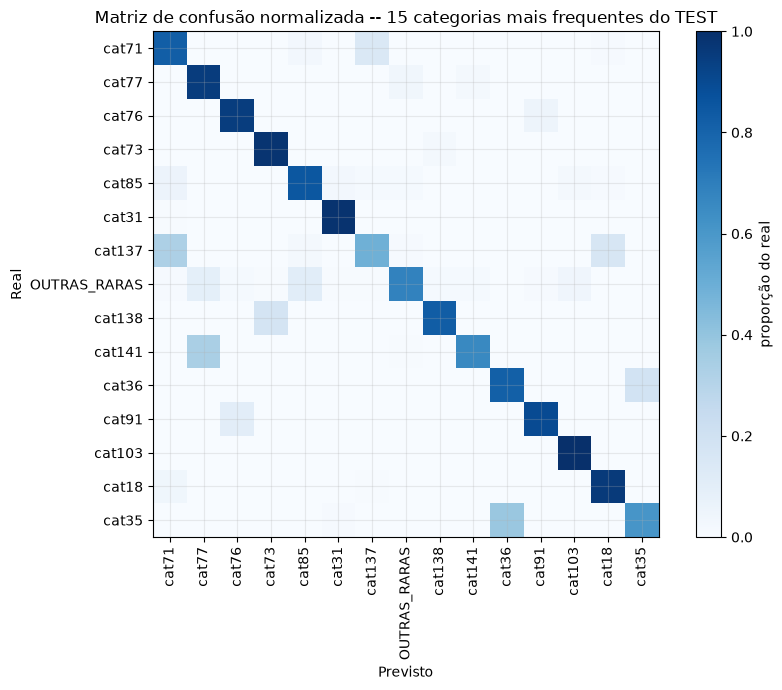

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

top15_vol = y_test.value_counts().head(15).index
mask15 = y_test.isin(top15_vol) & pd.Series(pred_test, index=y_test.index).isin(top15_vol)
cm = confusion_matrix(y_test[mask15], pd.Series(pred_test, index=y_test.index)[mask15], labels=top15_vol, normalize="true")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(top15_vol))); ax.set_xticklabels(top15_vol, rotation=90)
ax.set_yticks(range(len(top15_vol))); ax.set_yticklabels(top15_vol)
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusão normalizada -- 15 categorias mais frequentes do TEST")
fig.colorbar(im, ax=ax, label="proporção do real")
plt.tight_layout()
plt.show()

In [44]:
print("Accuracy por canal (TEST):")
acc_canal = (pd.DataFrame({"real": y_test.values, "pred": pred_test, "canal": test["Aberto por"].values})
             .groupby("canal").apply(lambda g: accuracy_score(g["real"], g["pred"])))
print(acc_canal.round(4))

print("\nTaxa de erro por Produto (produtos com >=30 casos no TEST, top 10 piores):")
erro_produto = test.assign(erro=(pred_test != y_test.values)).groupby("Produto")["erro"].agg(["mean", "count"])
print(erro_produto.query("count >= 30").sort_values("mean", ascending=False).head(10).round(3))

Accuracy por canal (TEST):
canal
Manual          0.757
Monitoramento   0.838
dtype: float64

Taxa de erro por Produto (produtos com >=30 casos no TEST, top 10 piores):
              mean  count
Produto                  
Desconhecido 0.569     72
lrev         0.517    722
lexc         0.492     61
lcsp         0.373     51
lvps         0.361    119
lsg2         0.356     45
lemg         0.348     69
lsd0         0.344     32
lrdo         0.330    106
khvp         0.314     51


**Matriz de confusão → insight → implicação**

Recall alto na maioria das categorias mais volumosas, com duas exceções: `cat85` e,
principalmente, `cat137`, que erra quase metade das vezes. O par `cat71` ↔ `cat137` é a
confusão mais frequente do TEST, nos dois sentidos — sugere que essas duas categorias têm
descrição e produto parecidos o bastante para confundir um modelo que só enxerga texto +
estrutura, sem o contexto que só aparece durante o atendimento.

**Outros achados:**

- O agrupamento `OUTRAS_RARAS` (Seção 08) funciona na prática: nenhuma das 46 classes finais
  fica sem exemplo no TEST.
- Accuracy por canal não piora em Monitoramento — a mudança de mix de canal entre TRAIN e TEST
  (Seção 07) não virou prejuízo real, o que também justifica ter tirado `Aberto por` do
  pipeline: o canal não carrega sinal confiável, para o bem e para o mal.
- `lrev` é o produto com pior desempenho relativo **e** volume relevante — a oportunidade de
  melhoria mais concreta.
- A queda em dezembro é deriva temporal, não bug de pipeline — o corte de regime já está
  inteiramente dentro do TRAIN.

**Limitação:** para as 25 categorias que nunca aparecem fora do TRAIN (Seção 07), hoje dentro
de `OUTRAS_RARAS`, não dá para falar do recall de cada uma individualmente — só do grupo como
um todo.

## 19 — Aplicação prática

O modelo de produção é retreinado em TRAIN+VAL — mais dado, já que os hiperparâmetros foram
decididos sem olhar o TEST. Só o TEST fica de fora, por ser o único conjunto nunca visto até
aqui.

O exemplo abaixo usa um incidente P2/P3 sem `Categoria`, aberto depois de 01/09/2025 —
exatamente o cenário da Seção 04: é ali que a categorização automática do canal Monitoramento
parou de funcionar, e é ali que este modelo tem valor real.

In [45]:
train_val = pd.concat([train, val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

vec_prod = TfidfVectorizer(ngram_range=TFIDF_NGRAM, min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
Xt_trval_prod = vec_prod.fit_transform(train_val["Descrição resumida"])

(Xs_trval_prod,), ohe_prod = build_estruturado(train_val, [train_val], incluir_canal=False)

Xh_trval_prod = hstack([Xt_trval_prod, Xs_trval_prod]).tocsr()

modelo_producao = LinearSVC(C=MELHOR_C, class_weight=MELHOR_CLASS_WEIGHT, random_state=RANDOM_STATE, max_iter=5000)
modelo_producao.fit(Xh_trval_prod, y_train_val)
print("Modelo de produção treinado em TRAIN+VAL:", Xh_trval_prod.shape)

Modelo de produção treinado em TRAIN+VAL: (25709, 3122)


In [46]:
df_aplicacao_pos_regime = df_aplicacao[df_aplicacao["Aberto"] >= "2025-09-01"].copy()
print(f"P2/P3 sem Categoria, Aberto >= 01/09/2025: {len(df_aplicacao_pos_regime):,} registros "
      f"(de {len(df_aplicacao):,} no total de aplicação futura)")

exemplo = df_aplicacao_pos_regime.sample(1, random_state=RANDOM_STATE).copy()
exemplo["Produto"] = exemplo["Produto"].fillna("Desconhecido")
exemplo["Item de configuração"] = exemplo["Item de configuração"].fillna("Desconhecido")
exemplo["Descrição resumida"] = exemplo["Descrição resumida"].fillna("")
exemplo["_ic_bucket"] = bucket_ic(exemplo["Item de configuração"])

exemplo[["Número", "Prioridade", "Produto", "Item de configuração", "Aberto", "Descrição resumida", "Aberto por"]]

P2/P3 sem Categoria, Aberto >= 01/09/2025: 21,530 registros (de 22,353 no total de aplicação futura)


,Número,Prioridade,Produto,Item de configuração,Aberto,Descrição resumida,Aberto por
883,INC8653081,3 - Média,Desconhecido,IC00108,2025-12-30 20:10:40,Problem: Disk I/O is overloaded on IC00108,Monitoramento


In [47]:
Xt_ex = vec_prod.transform(exemplo["Descrição resumida"])
Xs_ex = hstack([ohe_prod.transform(exemplo[["Prioridade", "Produto"]]), csr_matrix(ic_freq_feature(exemplo))]).tocsr()
Xh_ex = hstack([Xt_ex, Xs_ex]).tocsr()

scores_ex = modelo_producao.decision_function(Xh_ex)[0]
top3_idx = np.argsort(scores_ex)[::-1][:3]
top3_cats = modelo_producao.classes_[top3_idx]
top3_scores = scores_ex[top3_idx]

print("Incidente:", exemplo["Número"].values[0])
print("Descrição:", exemplo["Descrição resumida"].values[0])
print("Produto:", exemplo["Produto"].values[0], "| Prioridade:", exemplo["Prioridade"].values[0])
print("\nTop-3 categorias sugeridas pelo modelo:")
for cat, score in zip(top3_cats, top3_scores):
    print(f"  {cat:15s} score={score:.3f}")
print("\n(Não é possível calcular Accuracy aqui -- não existe Categoria observada para "
      "este registro; é exatamente o cenário de uso real em produção.)")

Incidente: INC8653081
Descrição: Problem: Disk I/O is overloaded on IC00108
Produto: Desconhecido | Prioridade: 3 - Média

Top-3 categorias sugeridas pelo modelo:
  OUTRAS_RARAS    score=-0.074
  cat135          score=-0.574
  cat76           score=-0.642

(Não é possível calcular Accuracy aqui -- não existe Categoria observada para este registro; é exatamente o cenário de uso real em produção.)


## 20 — Conclusão

**O modelo é viável?** Sim, dentro do que foi testado. Bate a meta de Accuracy com folga e,
mais importante, resolve o problema estrutural do baseline: onde o baseline por Produto só
acerta a categoria mais comum de cada produto, o modelo final generaliza também para as
categorias raras (F1-Macro quase 3x maior — tabela da Seção 17).

**O que ele aprendeu?** Que texto e estrutura são complementares — nenhum dos dois sozinho
chega perto do híbrido. `Produto` carrega mais sinal que a descrição isolada, mas é a
combinação que destrava o resultado. Canal de abertura e horário/dia/mês não ajudam — testados
e descartados por evidência (Seção 15), não por suposição.

**Onde ele ajuda?** No cenário real do notebook: incidentes P2/P3 sem `Categoria`, concentrados
no canal Monitoramento depois de 01/09/2025 (Seção 04) — exatamente onde a categorização
automática do processo atual parou de funcionar. Top-3 cobre a grande maioria dos casos reais,
então mesmo quando erra a primeira sugestão, raramente erra as três.

**Limitações:**

- `cat137` é confundida com `cat71` quase metade das vezes — maior ponto fraco identificado.
- `lrev` concentra volume e erro alto ao mesmo tempo — alvo concreto de melhoria.
- 25 categorias originais nunca aparecem fora do TRAIN — não dá para avaliar o recall
  individual delas, só do grupo `OUTRAS_RARAS`.
- Não é possível confirmar, só com a base, se `Prioridade` é o valor da abertura ou uma
  reclassificação posterior.
- O desempenho cai em dezembro, mês mais distante do TRAIN — sinal de que o modelo precisa de
  retreino periódico, não é treino único e definitivo.

**Como complementa o projeto principal:** o Sprint 3 prevê quando o volume de incidentes vai
subir; este notebook ajuda a organizar o que já chegou, sugerindo a categoria certa no momento
da abertura — duas pontas do mesmo problema operacional, uma antecipando demanda, outra
apoiando a triagem.

**Próximos passos:** investigar por que `cat71`/`cat137` se confundem (pode ser sobreposição de
definição, não só limite do modelo); tratar `lrev` como caso à parte; reavaliar o corte de
classes raras com mais dados de 2026; considerar retreino programado, dado o padrão de queda ao
longo do TEST.